In [1]:
!git clone -b fakequant https://github.com/dymnmysn/MiDaSFPGA.git
!cd MiDaSFPGA; git pull
!pip install fiftyone

import fiftyone
dataset = fiftyone.zoo.load_zoo_dataset(
    "coco-2017",
    split="validation",
    label_types=["detections", "segmentations"],
    classes=["person", "car"],
    max_samples=50,
)

!mv /root/fiftyone/coco-2017/validation/data /kaggle/working/data
!wget https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt
!mv midas_v21_small_256.pt /kaggle/working/MiDaSFPGA/weights/

from IPython.display import clear_output
clear_output(wait=True)

Cloning into 'MiDaSFPGA'...
remote: Enumerating objects: 460, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 460 (delta 58), reused 29 (delta 5), pack-reused 328 (from 1)
Receiving objects: 100% (460/460), 20.75 MiB | 30.48 MiB/s, done.
Resolving deltas: 100% (200/200), done.
Already up to date.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


 100% |██████|    1.9Gb/1.9Gb [2.5s elapsed, 0s remaining, 762.9Mb/s]       
Extracting annotations to '/root/fiftyone/coco-2017/raw/instances_val2017.json'
 100% |████████████████████| 50/50 [2.7s elapsed, 0s remaining, 19.9 images/s]      
Writing annotations for 50 downloaded samples to '/root/fiftyone/coco-2017/validation/labels.json'
Dataset info written to '/root/fiftyone/coco-2017/info.json'
Loading 'coco-2017' split 'validation'
 100% |███████████████████| 50/50 [1.5s elapsed, 0s remaining, 34.2 samples/s]         
Dataset 'coco-2017-validation-50' created
--2026-02-02 16:22:01--  https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/193518067/eccb1fd6-8775-468e-b609-263912546d77?sp=r&sv=2018-11-09&sr

In [2]:
import sys
sys.path.append("/kaggle/working/MiDaSFPGA")

In [3]:
!ls /kaggle/working/data/data |wc

ls: cannot access '/kaggle/working/data/data': No such file or directory
      0       0       0


In [4]:
import cv2
import torch
import urllib.request
import numpy as np

import matplotlib.pyplot as plt

url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
urllib.request.urlretrieve(url, filename)

('dog.jpg', <http.client.HTTPMessage at 0x7ad0aaba06b0>)

In [5]:
!cd MiDaSFPGA; git pull

Already up to date.


In [6]:
from midasfpga.configs.midas_config import Midas_Config
from midasfpga.utils.func_utils import get_midas_transform, get_model
from PIL import Image
import os
import cv2


conf = Midas_Config()
model, device = get_model(conf)
transform = get_midas_transform()
sample_img = transform(Image.open('/kaggle/working/dog.jpg')).unsqueeze(0).to(device)
sample_img = transform(Image.open('/kaggle/working/dog.jpg')).unsqueeze(0).to(device)
sample_img = transform(Image.open('/kaggle/working/dog.jpg')).unsqueeze(0).to(device)

coco_batches = {}

for file in os.listdir("/kaggle/working/data"):
    if file.endswith(".jpg"):
        filename = os.path.join("/kaggle/working/data", file)

        img = Image.open(filename).convert("RGB")
        input_batch = transform(img).to(device)

        h, w = input_batch.shape[-2:]
        key = (h, w)

        if key not in coco_batches:
            coco_batches[key] = []

        coco_batches[key].append(input_batch)


batch = coco_batches[(192,256)]
batch = torch.stack(batch,dim=0)
coco_batch=batch
print("The shape of the quantization batch is",coco_batch.shape)
coco_batches = [coco_batch[4*idx:4*idx+4,...] for idx in range(coco_batch.shape[0]//4)]
print("The shape of a single coco batch is", coco_batches[0].shape)

Testing on cpu device.
Loading weights:  None


/usr/local/lib/python3.12/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
The shape of the quantization batch is torch.Size([50, 3, 192, 256])
The shape of a single coco batch is torch.Size([4, 3, 192, 256])


In [7]:
shapes = [c.shape for c in coco_batches]
shapes

[torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256]),
 torch.Size([4, 3, 192, 256])]

In [8]:
#model_type = "DPT_Large"     # MiDaS v3 - Large     (highest accuracy, slowest inference speed)
#model_type = "DPT_Hybrid"   # MiDaS v3 - Hybrid    (medium accuracy, medium inference speed)
model_type = "MiDaS_small"  # MiDaS v2.1 - Small   (lowest accuracy, highest inference speed)

#midas = torch.hub.load("intel-isl/MiDaS", model_type)
midas = model

In [9]:

device = torch.device("cpu")#torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
midas.eval()
print('Done')

Done


In [10]:
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [11]:
input_batch = sample_img

In [12]:
sample_img

tensor([[[[-1.8953, -1.8439, -1.8097,  ..., -2.0494, -2.0323, -1.9124],
          [-1.9809, -1.9295, -1.8953,  ..., -2.0323, -2.0152, -1.9638],
          [-1.9809, -1.9809, -1.9980,  ..., -1.8953, -1.9467, -1.9638],
          ...,
          [-1.5528, -1.5357, -1.5014,  ..., -1.5185, -1.3987, -1.2959],
          [-1.6727, -1.3473, -1.2103,  ..., -1.4843, -1.2788, -1.1760],
          [-1.3302, -1.0390, -1.1589,  ..., -1.4158, -1.4672, -1.0562]],

         [[-1.6681, -1.6331, -1.6331,  ..., -1.9307, -1.8256, -1.5980],
          [-1.7906, -1.7206, -1.6331,  ..., -1.9657, -1.9132, -1.8081],
          [-1.7556, -1.8256, -1.8606,  ..., -1.6681, -1.7556, -1.7556],
          ...,
          [-0.8277, -0.9503, -0.8803,  ..., -0.8277, -0.6877, -0.5126],
          [-1.0028, -0.8102, -0.5826,  ..., -0.7577, -0.5826, -0.4426],
          [-0.7577, -0.5826, -0.6001,  ..., -0.7927, -0.7752, -0.3901]],

         [[-1.5430, -1.4907, -1.4907,  ..., -1.7173, -1.6999, -1.6127],
          [-1.6650, -1.6650, -

In [13]:
with torch.no_grad():
    prediction = midas.cpu()(input_batch.cpu())
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=input_batch.shape[2:],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output_float = prediction.cpu().numpy()

In [14]:
prediction.shape

torch.Size([192, 256])

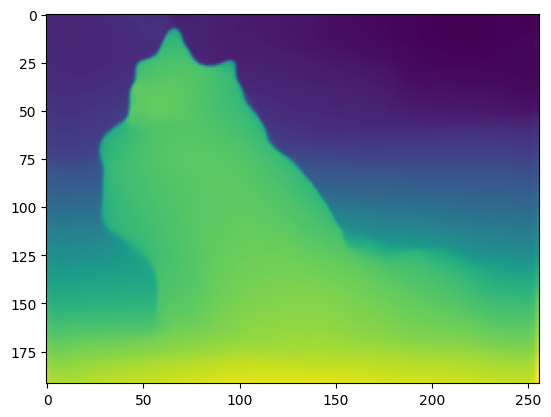

In [15]:
plt.imshow(output_float)
# plt.show()

In [16]:
# ============================================================
# Static-activation fake quant (calibrate -> freeze -> inference)
# Copy-paste ready. PyTorch only.
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from typing import Tuple, Optional, Iterable, Union

# ----------------------------
# Quant helpers
# ----------------------------

def _quant_range(bits: int, signed: bool) -> Tuple[int, int]:
    if bits < 2:
        raise ValueError("bits must be >= 2")
    if signed:
        qmin = -(2 ** (bits - 1))
        qmax = (2 ** (bits - 1)) - 1
    else:
        qmin = 0
        qmax = (2 ** bits) - 1
    return qmin, qmax

@torch.no_grad()
def fake_quant_affine(
    x: torch.Tensor,
    bits: int,
    scale: torch.Tensor,
    zero_point: torch.Tensor,
    signed: bool,
) -> torch.Tensor:
    """
    Fake-quantize tensor using fixed affine qparams:
        x_int = clamp(round(x/scale + zp), qmin, qmax)
        x_hat = (x_int - zp) * scale
    scale/zp may be scalar or per-channel (broadcastable).
    """
    qmin, qmax = _quant_range(bits, signed)
    x_int = torch.round(x / scale + zero_point).clamp(qmin, qmax)
    return (x_int - zero_point) * scale


# ----------------------------
# Observers (calibration only)
# ----------------------------

class EMAMinMaxObserver(nn.Module):
    """
    Running EMA min/max observer.
    - per_channel: compute per-channel min/max (channel axis ch_axis)
    - momentum: closer to 1.0 => slower updates (more smoothing)
    """
    def __init__(self, per_channel: bool = False, ch_axis: int = 1, momentum: float = 0.95, eps: float = 1e-8):
        super().__init__()
        self.per_channel = per_channel
        self.ch_axis = ch_axis
        self.momentum = momentum
        self.eps = eps

        self.register_buffer("_min", torch.tensor(0.0))
        self.register_buffer("_max", torch.tensor(0.0))
        self._inited = False

    @torch.no_grad()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.per_channel:
            dims = [d for d in range(x.ndim) if d != self.ch_axis]
            cur_min = x.amin(dim=dims)
            cur_max = x.amax(dim=dims)
        else:
            cur_min = x.amin()
            cur_max = x.amax()

        if not self._inited:
            self._min = cur_min.clone()
            self._max = cur_max.clone()
            self._inited = True
        else:
            m = self.momentum
            self._min = m * self._min + (1.0 - m) * cur_min
            self._max = m * self._max + (1.0 - m) * cur_max

        return x

    @torch.no_grad()
    def calculate_qparams(self, bits: int, signed: bool) -> Tuple[torch.Tensor, torch.Tensor]:
        qmin, qmax = _quant_range(bits, signed)

        mn = self._min
        mx = self._max

        # avoid degenerate ranges
        mx = torch.maximum(mx, mn + self.eps)

        scale = (mx - mn) / float(qmax - qmin)
        scale = torch.clamp(scale, min=self.eps)

        # affine asymmetric zp
        zp = qmin - torch.round(mn / scale)
        zp = torch.clamp(zp, qmin, qmax)

        return scale, zp


# ----------------------------
# Weight qparams (typically symmetric)
# ----------------------------

@torch.no_grad()
def calc_weight_qparams_symmetric(
    w: torch.Tensor,
    bits: int,
    per_channel: bool = True,
    ch_axis: int = 0,
    eps: float = 1e-8,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Symmetric quant for weights: zero_point = 0, scale = max_abs / qmax
    Returns (scale, zero_point) broadcastable to w.
    """
    qmin, qmax = _quant_range(bits, signed=True)  # weights are signed in this function
    if per_channel:
        dims = [d for d in range(w.ndim) if d != ch_axis]
        max_abs = w.abs().amax(dim=dims).clamp_min(eps)
        scale = (max_abs / float(qmax)).clamp_min(eps)
        # reshape for broadcasting: put channel dimension at ch_axis
        shape = [1] * w.ndim
        shape[ch_axis] = -1
        scale = scale.reshape(shape)
        zp = torch.zeros_like(scale)
    else:
        max_abs = w.abs().amax().clamp_min(eps)
        scale = (max_abs / float(qmax)).clamp_min(eps)
        zp = torch.tensor(0.0, device=w.device, dtype=w.dtype)
    return scale, zp


# ----------------------------
# FakeQuant wrappers
# ----------------------------

class FakeQuantConv2d(nn.Module):
    """
    Conv2d wrapper:
      - Activation: STATIC affine fake-quant with frozen qparams (collected during calibration)
      - Weight: symmetric fake-quant (frozen by default, computed once)
    """
    def __init__(
        self,
        conv: nn.Conv2d,
        *,
        w_bits: int = 4,
        a_bits: int = 8,
        w_per_channel: bool = True,
        a_per_channel: bool = False,
        act_signed: bool = True,
        act_ch_axis: int = 1,
        obs_momentum: float = 0.95,
        eps: float = 1e-8,
    ):
        super().__init__()
        self.conv = conv

        self.w_bits = w_bits
        self.a_bits = a_bits
        self.w_per_channel = w_per_channel
        self.a_per_channel = a_per_channel
        self.act_signed = act_signed
        self.eps = eps

        # Calibration state
        self.calibrating = True
        self.act_frozen = False
        self.w_frozen = False

        self.act_obs = EMAMinMaxObserver(per_channel=a_per_channel, ch_axis=act_ch_axis, momentum=obs_momentum, eps=eps)

        # Frozen qparams (buffers)
        self.register_buffer("a_scale", torch.tensor(1.0))
        self.register_buffer("a_zero_point", torch.tensor(0.0))
        self.register_buffer("w_scale", torch.tensor(1.0))
        self.register_buffer("w_zero_point", torch.tensor(0.0))

    @torch.no_grad()
    def freeze_act_qparams(self):
        scale, zp = self.act_obs.calculate_qparams(self.a_bits, signed=self.act_signed)
        self.a_scale = scale
        self.a_zero_point = zp
        self.act_frozen = True
        self.calibrating = False

    @torch.no_grad()
    def freeze_weight_qparams(self):
        scale, zp = calc_weight_qparams_symmetric(
            self.conv.weight, bits=self.w_bits, per_channel=self.w_per_channel, ch_axis=0, eps=self.eps
        )
        self.w_scale = scale
        self.w_zero_point = zp
        self.w_frozen = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Activation path
        if self.calibrating:
            self.act_obs(x)
            xq = x  # keep float during calibration (common for PTQ)
        else:
            if not self.act_frozen:
                raise RuntimeError("Activation qparams not frozen. Run calibration then freeze_act_qparams().")
            xq = fake_quant_affine(x, self.a_bits, self.a_scale, self.a_zero_point, signed=self.act_signed)

        # Weight path
        if not self.w_frozen:
            self.freeze_weight_qparams()
        wq = fake_quant_affine(self.conv.weight, self.w_bits, self.w_scale, self.w_zero_point, signed=True)

        return F.conv2d(xq, wq, self.conv.bias, self.conv.stride, self.conv.padding, self.conv.dilation, self.conv.groups)


class FakeQuantLinear(nn.Module):
    """
    Linear wrapper with the same policy as FakeQuantConv2d.
    """
    def __init__(
        self,
        linear: nn.Linear,
        *,
        w_bits: int = 4,
        a_bits: int = 8,
        w_per_channel: bool = True,
        a_per_channel: bool = False,
        act_signed: bool = True,
        act_ch_axis: int = -1,  # for [N,features], channel axis is last
        obs_momentum: float = 0.95,
        eps: float = 1e-8,
    ):
        super().__init__()
        self.linear = linear

        self.w_bits = w_bits
        self.a_bits = a_bits
        self.w_per_channel = w_per_channel
        self.a_per_channel = a_per_channel
        self.act_signed = act_signed
        self.eps = eps

        self.calibrating = True
        self.act_frozen = False
        self.w_frozen = False

        self.act_obs = EMAMinMaxObserver(per_channel=a_per_channel, ch_axis=act_ch_axis, momentum=obs_momentum, eps=eps)

        self.register_buffer("a_scale", torch.tensor(1.0))
        self.register_buffer("a_zero_point", torch.tensor(0.0))
        self.register_buffer("w_scale", torch.tensor(1.0))
        self.register_buffer("w_zero_point", torch.tensor(0.0))

    @torch.no_grad()
    def freeze_act_qparams(self):
        scale, zp = self.act_obs.calculate_qparams(self.a_bits, signed=self.act_signed)
        self.a_scale = scale
        self.a_zero_point = zp
        self.act_frozen = True
        self.calibrating = False

    @torch.no_grad()
    def freeze_weight_qparams(self):
        # per-channel over out_features axis=0 for [out,in]
        scale, zp = calc_weight_qparams_symmetric(
            self.linear.weight, bits=self.w_bits, per_channel=self.w_per_channel, ch_axis=0, eps=self.eps
        )
        self.w_scale = scale
        self.w_zero_point = zp
        self.w_frozen = True

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.calibrating:
            self.act_obs(x)
            xq = x
        else:
            if not self.act_frozen:
                raise RuntimeError("Activation qparams not frozen. Run calibration then freeze_act_qparams().")
            xq = fake_quant_affine(x, self.a_bits, self.a_scale, self.a_zero_point, signed=self.act_signed)

        if not self.w_frozen:
            self.freeze_weight_qparams()
        wq = fake_quant_affine(self.linear.weight, self.w_bits, self.w_scale, self.w_zero_point, signed=True)

        return F.linear(xq, wq, self.linear.bias)


# ----------------------------
# Model conversion (Conv2d / Linear only)
# ----------------------------

@dataclass
class FakeQuantConfig:
    w_bits: int = 4
    a_bits: int = 8
    w_per_channel: bool = True
    a_per_channel: bool = False
    # Choose signed/unsigned activations:
    # - If your model uses ReLU right before the quant point, unsigned can help.
    # - Otherwise keep signed=True.
    act_signed: bool = True
    obs_momentum: float = 0.95
    eps: float = 1e-8

def convert_to_fakequant_static_act(model: nn.Module, cfg: FakeQuantConfig) -> nn.Module:
    """
    Recursively replaces Conv2d and Linear with FakeQuant wrappers.
    Safe to call on an existing model; returns the same object modified in-place.
    """
    for name, child in list(model.named_children()):
        # Recurse first
        convert_to_fakequant_static_act(child, cfg)

        if isinstance(child, nn.Conv2d):
            wrapped = FakeQuantConv2d(
                child,
                w_bits=cfg.w_bits,
                a_bits=cfg.a_bits,
                w_per_channel=cfg.w_per_channel,
                a_per_channel=cfg.a_per_channel,
                act_signed=cfg.act_signed,
                obs_momentum=cfg.obs_momentum,
                eps=cfg.eps,
            )
            setattr(model, name, wrapped)

        elif isinstance(child, nn.Linear):
            wrapped = FakeQuantLinear(
                child,
                w_bits=cfg.w_bits,
                a_bits=cfg.a_bits,
                w_per_channel=cfg.w_per_channel,
                a_per_channel=cfg.a_per_channel,
                act_signed=cfg.act_signed,
                obs_momentum=cfg.obs_momentum,
                eps=cfg.eps,
            )
            setattr(model, name, wrapped)

    return model


# ----------------------------
# Calibration / freezing utilities
# ----------------------------

def set_calibration(model: nn.Module, enabled: bool):
    for m in model.modules():
        if hasattr(m, "calibrating"):
            m.calibrating = enabled

@torch.no_grad()
def freeze_qparams(model: nn.Module):
    """
    Freeze activation qparams for all wrapped layers.
    Also freeze weight qparams (computed once).
    """
    for m in model.modules():
        if hasattr(m, "freeze_weight_qparams"):
            m.freeze_weight_qparams()
        if hasattr(m, "freeze_act_qparams"):
            m.freeze_act_qparams()

@torch.no_grad()
def run_calibration(model: nn.Module, calib_iter: Iterable[torch.Tensor], device: Union[str, torch.device] = "cpu"):
    """
    Run forward passes to collect activation stats.
    calib_iter yields model inputs (x) or tuples/lists (x, ...) if your model needs more.
    """
    model.eval()
    model.to(device)
    set_calibration(model, True)

    for batch in calib_iter:
        if isinstance(batch, (tuple, list)):
            batch = [b.to(device) if torch.is_tensor(b) else b for b in batch]
            _ = model(*batch)
        else:
            x = batch.to(device) if torch.is_tensor(batch) else batch
            _ = model(x)

    freeze_qparams(model)
    set_calibration(model, False)
    model.eval()
    return model

OK, output shape: torch.Size([1, 224, 224])


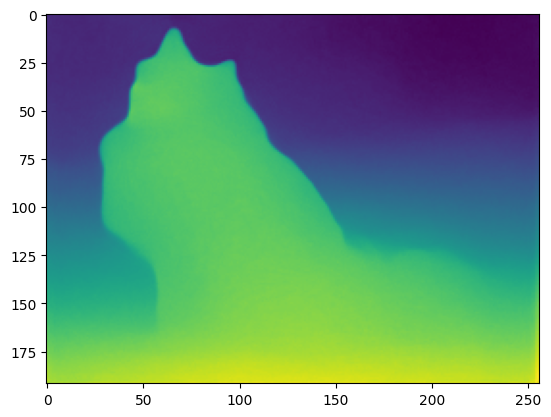

In [17]:
import copy
m = copy.deepcopy(midas)


cfg = FakeQuantConfig(w_bits=8, a_bits=8, w_per_channel=True, a_per_channel=False, act_signed=True)

fq_model = convert_to_fakequant_static_act(m, cfg)

# Fake calibration data (replace with real calibration loader)
#calib_batches = [torch.randn(4, 3, 224, 224) for _ in range(8)]
calib_batches = coco_batches

fq_m = run_calibration(fq_model, calib_batches, device="cpu")  # set to "cuda" if available

# Inference: activation qparams are frozen; NO min/max computed at runtime.
with torch.no_grad():
    y = fq_model(torch.randn(1, 3, 224, 224))
print("OK, output shape:", y.shape)

with torch.no_grad():
    prediction = fq_model(input_batch.cpu())
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=input_batch.shape[2:],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

output = prediction.cpu().numpy()
plt.imshow(output)


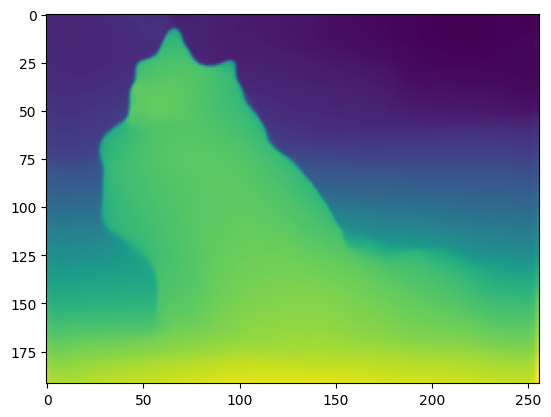

In [18]:
plt.imshow(output_float)

In [19]:
print("Relative absolute error between float and quantized model outputs:", np.absolute(output-output_float).mean()/(output_float+output).mean().item())

Relative absolute error between float and quantized model outputs: 0.004950645


In [20]:
import torch
import torch.utils.data as data
import torch.nn.functional as F
from tqdm import tqdm

from midasfpga.dataset.nyuv2 import NyuDepthV2
from midasfpga.utils.metric import BadPixelMetric
from midasfpga.utils.func_utils import get_midas_transform

# These must come from your notebook / codebase:
# - FakeQuantConfig
# - convert_to_fakequant_static_act
# - run_calibration
# And you already have:
# - midas (float model) or a function that returns it
# - coco_batches (calibration batches)



quant_list = ["W4A8", "W8A8"]  # extend
quant_list = [f"W{w}A{a}" for w in range(2, 11) for a in range(2, 11)]
CALIB_DEVICE = "cpu"          # your snippet uses cpu; switch to "cuda" if needed
EVAL_DEVICE = 'cpu'# "cuda" if torch.cuda.is_available() else "cpu"


def parse_quant(tag: str) -> tuple[int, int]:
    tag = tag.upper().strip()
    w = int(tag.split("A")[0][1:])
    a = int(tag.split("A")[1])
    return w, a


def build_calibrated_fq_model(midas_float_model, quant_tag: str, coco_batches):
    """
    Matches your notebook exactly:
      cfg -> convert_to_fakequant_static_act -> run_calibration
    """
    w_bits, a_bits = parse_quant(quant_tag)

    cfg = FakeQuantConfig(
        w_bits=w_bits,
        a_bits=a_bits,
        w_per_channel=True,
        a_per_channel=False,
        act_signed=True
    )

    fq_model = convert_to_fakequant_static_act(midas_float_model, cfg)

    # IMPORTANT: run_calibration returns the calibrated model with frozen act qparams.
    fq_model = run_calibration(fq_model, coco_batches, device=CALIB_DEVICE)

    # evaluation mode + move if you want GPU eval
    fq_model.eval().to(EVAL_DEVICE)
    return fq_model


def ensure_pred_b1hw(pred: torch.Tensor, target_hw):
    """
    Your notebook sometimes treats output as [H,W] and interpolates after unsqueeze(1).
    For metrics, we normalize to [B,1,H,W].
    """
    # Common MiDaS outputs:
    # - [B,H,W]
    # - [B,1,H,W]
    # - [H,W]
    if pred.dim() == 2:          # [H,W]
        pred = pred.unsqueeze(0).unsqueeze(0)
    elif pred.dim() == 3:        # [B,H,W]
        pred = pred.unsqueeze(1)
    elif pred.dim() == 4:        # [B,1,H,W] or [B,C,H,W]
        if pred.shape[1] != 1:
            # If model outputs channels >1 unexpectedly, pick channel 0 (adjust if needed)
            pred = pred[:, :1, :, :]
    else:
        raise ValueError(f"Unexpected pred shape: {tuple(pred.shape)}")

    pred = F.interpolate(
        pred,
        size=target_hw,
        mode="bicubic",
        align_corners=False,
    )
    return pred


def eval_nyuv2_for_model(fq_model, nyu_data_dir, index_len, partition_len=None):
    transform = get_midas_transform()
    metric = BadPixelMetric()

    d1_list, d2_list, d3_list = [], [], []

    for partition_index in range(index_len):
        ds = NyuDepthV2(nyu_data_dir, transform=transform, partition_index=partition_index)
        dl = data.DataLoader(ds, batch_size=1, num_workers=1, shuffle=False, pin_memory=True)

        bsum1 = bsum2 = bsum3 = 0.0

        for batch in tqdm(dl, desc=f"NYUv2 part {partition_index}"):
            # Your notebook uses CPU inference: fq_model(input_batch.cpu())
            # Here we mirror that but allow GPU eval if you moved the model.
            input_batch = batch["image"].to(EVAL_DEVICE)

            with torch.no_grad():
                pred = fq_model(input_batch)

            # mask is [1,H,W] usually
            target_hw = batch["mask"].shape[1:]
            pred = ensure_pred_b1hw(pred, target_hw)

            # depth may be [1,H,W] or [1,1,H,W] depending on dataset code; metric handles with mask
            depth = batch["depth"].to(torch.float32).to(EVAL_DEVICE)
            mask = batch["mask"]  # keep as is if metric expects CPU; move if required:
            # mask = batch["mask"].to(EVAL_DEVICE)
            #print(pred.shape,depth.shape,mask.shape)
            loss1, loss2, loss3, *_ = metric(pred.squeeze(1), depth, mask)

            bsum1 += float(loss1)
            bsum2 += float(loss2)
            bsum3 += float(loss3)

        n = len(ds)
        d1_list.append(bsum1 / n)
        d2_list.append(bsum2 / n)
        d3_list.append(bsum3 / n)

    return {
        "bad_pixel_delta1": sum(d1_list) / len(d1_list),
        "bad_pixel_delta2": sum(d2_list) / len(d2_list),
        "bad_pixel_delta3": sum(d3_list) / len(d3_list),
    }


# -----------------------
# MAIN SWEEP
# -----------------------
def run_sweep(midas_float_model, coco_batches, nyu_data_dir, fpga_index_length):
    results = []
    for q in quant_list:
        m = copy.deepcopy(midas)
        print(f"\n================ {q} ================\n")
        fq_model = build_calibrated_fq_model(m, q, coco_batches)
        metrics = eval_nyuv2_for_model(
            fq_model,
            nyu_data_dir=nyu_data_dir,
            index_len=fpga_index_length,
        )
        results.append({"quant": q, **metrics})

        print(f"{q}: d1={metrics['bad_pixel_delta1']:.3f} "
              f"d2={metrics['bad_pixel_delta2']:.3f} "
              f"d3={metrics['bad_pixel_delta3']:.3f}")
        del m

    return results


In [21]:
m = copy.deepcopy(midas)
results = run_sweep(
    midas_float_model=m,
    coco_batches=coco_batches,
    nyu_data_dir=conf.DATA_ROOT,
    fpga_index_length=conf.FPGA_INDEX_LENGTH
)


================ W2A2 ================



NYUv2 part 0:   0%|          | 0/109 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
NYUv2 part 5: 100%|██████████| 109/109 [00:24<00:00,  4.48it/s]


W2A2: d1=58.637 d2=25.939 d3=9.309

================ W2A3 ================



NYUv2 part 5: 100%|██████████| 109/109 [00:24<00:00,  4.39it/s]


W2A3: d1=58.106 d2=25.575 d3=9.108

================ W2A4 ================



...

W10A8: d1=18.021 d2=3.244 d3=0.721

================ W10A9 ================



NYUv2 part 5: 100%|██████████| 109/109 [00:29<00:00,  3.74it/s]


W10A9: d1=18.047 d2=3.260 d3=0.713

================ W10A10 ================



NYUv2 part 5: 100%|██████████| 109/109 [00:29<00:00,  3.67it/s]

W10A10: d1=18.026 d2=3.263 d3=0.714
